# Task 1: Exploratory Data Analysis
## AlphaCare Insurance Solutions (ACIS) — South Africa Auto Insurance

### Business Context
ACIS needs evidence-driven strategies to optimize marketing investments
and refine pricing models. This EDA analyzes 18 months of historical
claim data (Feb 2014 – Aug 2015) to:
- Assess data quality and understand key variables
- Identify low-risk customer segments for premium reduction
- Uncover geographic, vehicle, and demographic risk patterns
- Answer key business questions about loss ratios and profitability

### Key Metrics
- **Loss Ratio** = TotalClaims / TotalPremium (core profitability measure)
- **Margin** = TotalPremium − TotalClaims (per-policy profit)

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.chdir(r"C:\Users\pc\insurance-risk-analytics")
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

print("All imports successful")

All imports successful


In [16]:
# Load the pipe-separated text file
df = pd.read_csv(
    "data/MachineLearningRating_v3.txt",
    sep="|",
    low_memory=False
)

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset shape: (1000098, 52)
Rows: 1,000,098 | Columns: 52

Column names:
['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']


## Data Summarization

In [17]:
print("Data Types:")
print(df.dtypes.value_counts())
print("\nNumerical columns summary:")
numerical_cols = ['TotalPremium', 'TotalClaims', 'SumInsured',
                  'CalculatedPremiumPerTerm', 'CustomValueEstimate']
available_num = [c for c in numerical_cols if c in df.columns]
print(df[available_num].describe().round(2))

Data Types:
str        36
float64    11
int64       4
bool        1
Name: count, dtype: int64

Numerical columns summary:
       TotalPremium  TotalClaims   SumInsured  CalculatedPremiumPerTerm  \
count    1000098.00   1000098.00   1000098.00                1000098.00   
mean          61.91        64.86    604172.73                    117.88   
std          230.28      2384.07   1508331.84                    399.70   
min         -782.58    -12002.41         0.01                      0.00   
25%            0.00         0.00      5000.00                      3.22   
50%            2.18         0.00      7500.00                      8.44   
75%           21.93         0.00    250000.00                     90.00   
max        65282.60    393092.11  12636200.00                  74422.17   

       CustomValueEstimate  
count            220456.00  
mean             225531.13  
std              564515.75  
min               20000.00  
25%              135000.00  
50%              220000.00  

In [18]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("Columns with missing values (>0%):")
print(missing_df[missing_df['Missing Count'] > 0].head(20))

# Handle missing values
print(f"\nTotal missing values: {df.isnull().sum().sum():,}")
print(f"Total cells: {df.shape[0] * df.shape[1]:,}")
print(f"Missing %: {df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%")

Columns with missing values (>0%):
                         Missing Count  Missing %
NumberOfVehiclesInFleet        1000098     100.00
CrossBorder                     999400      99.93
CustomValueEstimate             779642      77.96
Rebuilt                         641901      64.18
Converted                       641901      64.18
WrittenOff                      641901      64.18
NewVehicle                      153295      15.33
Bank                            145961      14.59
AccountType                      40232       4.02
Gender                            9536       0.95
MaritalStatus                     8259       0.83
VehicleType                        552       0.06
make                               552       0.06
mmcode                             552       0.06
Model                              552       0.06
Cylinders                          552       0.06
bodytype                           552       0.06
kilowatts                          552       0.06
NumberOfDoors  

## Key Derived Metrics
We compute Loss Ratio and Margin as the two core business metrics.

In [19]:
# Avoid division by zero
df['LossRatio'] = np.where(
    df['TotalPremium'] > 0,
    df['TotalClaims'] / df['TotalPremium'],
    0
)
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

# Parse transaction month
if 'TransactionMonth' in df.columns:
    df['TransactionMonth'] = pd.to_datetime(
        df['TransactionMonth'], errors='coerce')

print(f"Overall Portfolio Loss Ratio: {df['LossRatio'].mean():.4f}")
print(f"Overall Portfolio Margin: R{df['Margin'].sum():,.2f}")
print(f"Total Premium Collected: R{df['TotalPremium'].sum():,.2f}")
print(f"Total Claims Paid: R{df['TotalClaims'].sum():,.2f}")
print(f"\nPolicies with claims: {(df['TotalClaims'] > 0).sum():,}")
print(f"Policies without claims: {(df['TotalClaims'] == 0).sum():,}")
print(f"Claim frequency: {(df['TotalClaims'] > 0).mean()*100:.2f}%")

Overall Portfolio Loss Ratio: 0.2164
Overall Portfolio Margin: R-2,955,983.47
Total Premium Collected: R61,911,562.70
Total Claims Paid: R64,867,546.17

Policies with claims: 2,788
Policies without claims: 997,305
Claim frequency: 0.28%


## Plot 1: Loss Ratio by Province
Geographic risk differences drive regional premium adjustments.

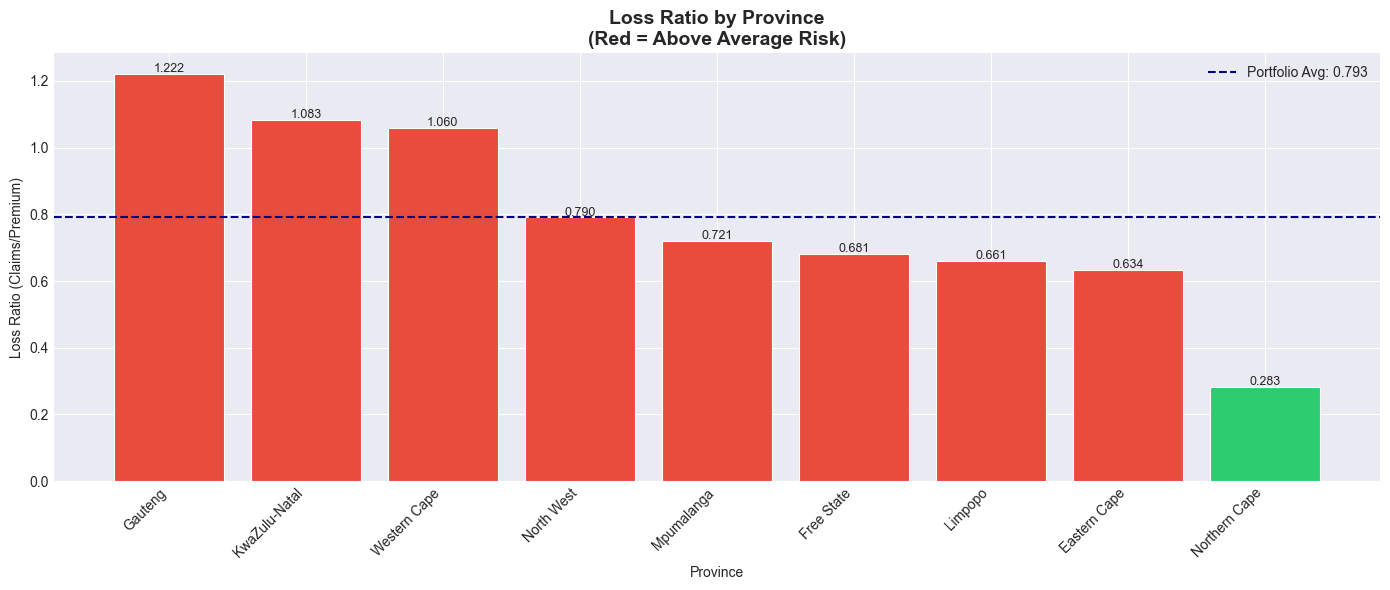

               Avg_Loss_Ratio  Total_Premium  Total_Claims  Policy_Count  \
Province                                                                   
Gauteng                0.2622   2.405377e+07  2.939415e+07        393865   
KwaZulu-Natal          0.1749   1.320908e+07  1.430138e+07        169781   
Western Cape           0.1936   9.806559e+06  1.038977e+07        170796   
North West             0.1788   7.490508e+06  5.920250e+06        143287   
Mpumalanga             0.2359   2.836292e+06  2.044675e+06         52718   
Free State             0.0778   5.213632e+05  3.549223e+05          8099   
Limpopo                0.2529   1.537324e+06  1.016477e+06         24836   
Eastern Cape           0.1530   2.140104e+06  1.356427e+06         30336   
Northern Cape          0.1164   3.165581e+05  8.949051e+04          6380   

               Portfolio_Loss_Ratio  
Province                             
Gauteng                      1.2220  
KwaZulu-Natal                1.0827  
Western Cap

In [20]:
if 'Province' in df.columns:
    province_stats = df.groupby('Province').agg(
        Avg_Loss_Ratio=('LossRatio', 'mean'),
        Total_Premium=('TotalPremium', 'sum'),
        Total_Claims=('TotalClaims', 'sum'),
        Policy_Count=('PolicyID', 'count')
    ).round(4)
    province_stats['Portfolio_Loss_Ratio'] = (
        province_stats['Total_Claims'] / province_stats['Total_Premium']
    ).round(4)
    province_stats = province_stats.sort_values(
        'Portfolio_Loss_Ratio', ascending=False)

    fig, ax = plt.subplots(figsize=(14, 6))
    colors = ['#e74c3c' if x > 0.5 else '#2ecc71' 
              for x in province_stats['Portfolio_Loss_Ratio']]
    bars = ax.bar(province_stats.index,
                  province_stats['Portfolio_Loss_Ratio'],
                  color=colors, edgecolor='white', linewidth=0.8)
    ax.axhline(y=province_stats['Portfolio_Loss_Ratio'].mean(),
               color='navy', linestyle='--', linewidth=1.5,
               label=f"Portfolio Avg: {province_stats['Portfolio_Loss_Ratio'].mean():.3f}")
    ax.set_title("Loss Ratio by Province\n(Red = Above Average Risk)",
                 fontsize=14, fontweight='bold')
    ax.set_xlabel("Province")
    ax.set_ylabel("Loss Ratio (Claims/Premium)")
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    for bar, val in zip(bars, province_stats['Portfolio_Loss_Ratio']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig("notebooks/plot1_loss_ratio_province.png",
                dpi=100, bbox_inches='tight')
    plt.show()
    print(province_stats)

## Plot 2: Distribution of Key Financial Variables
Understanding the distribution shape guides modeling decisions.

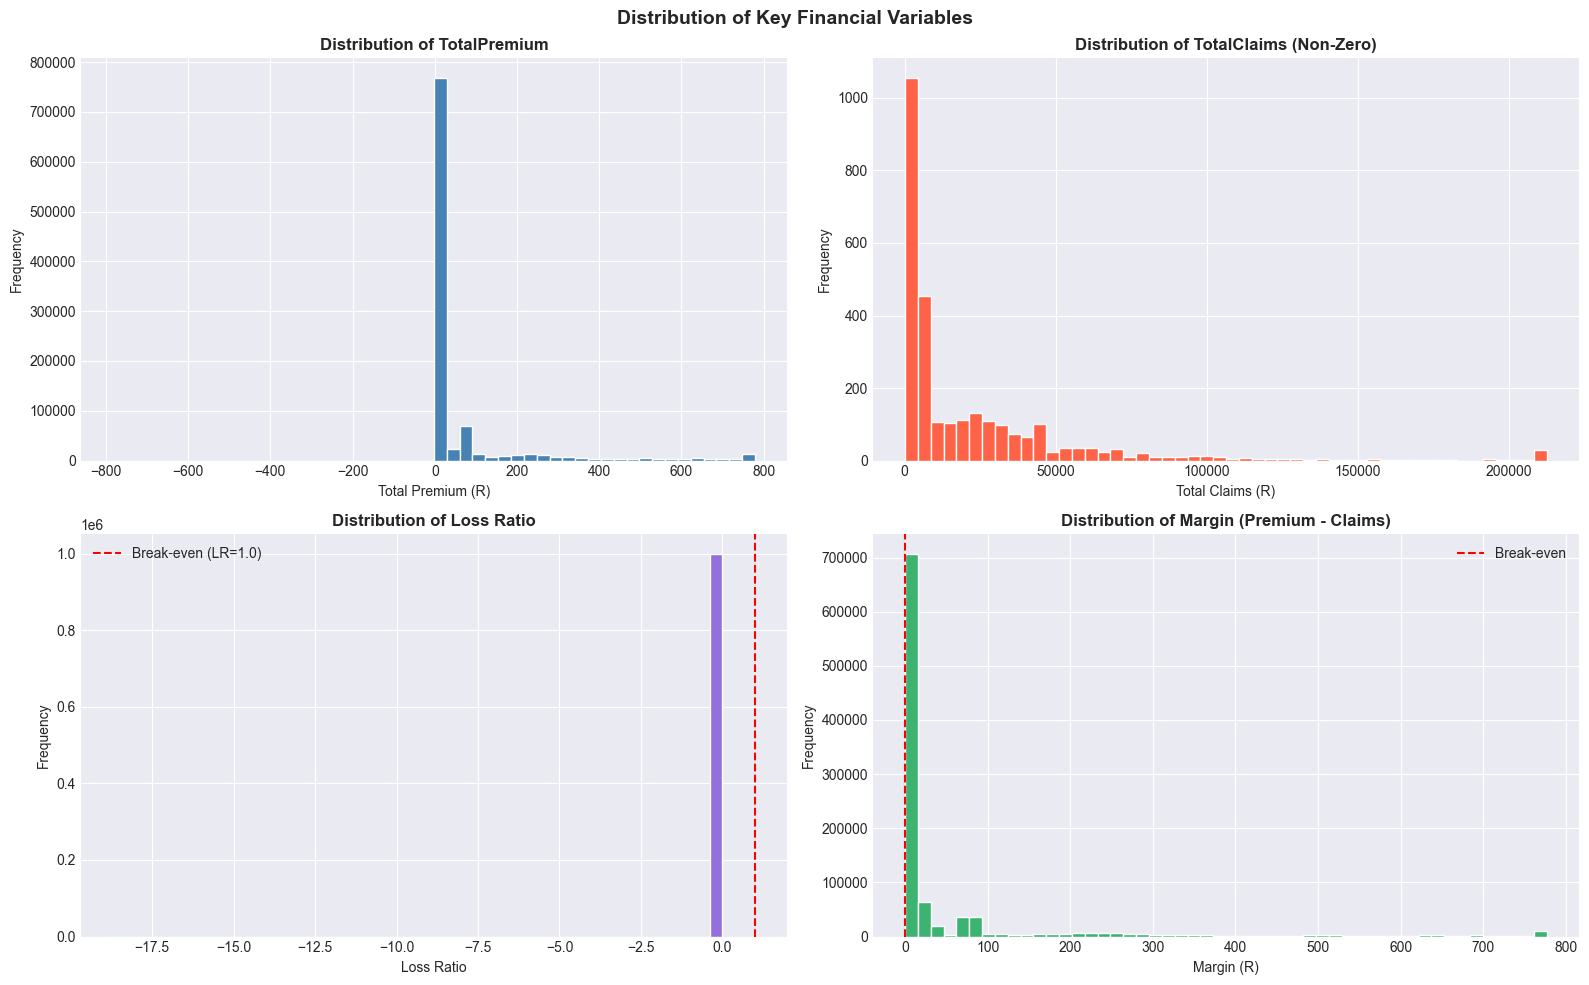

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# TotalPremium
axes[0,0].hist(df['TotalPremium'].clip(upper=df['TotalPremium'].quantile(0.99)),
               bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribution of TotalPremium', fontweight='bold')
axes[0,0].set_xlabel('Total Premium (R)')
axes[0,0].set_ylabel('Frequency')

# TotalClaims (non-zero only)
claims_nonzero = df[df['TotalClaims'] > 0]['TotalClaims']
axes[0,1].hist(claims_nonzero.clip(upper=claims_nonzero.quantile(0.99)),
               bins=50, color='tomato', edgecolor='white')
axes[0,1].set_title('Distribution of TotalClaims (Non-Zero)',
                    fontweight='bold')
axes[0,1].set_xlabel('Total Claims (R)')
axes[0,1].set_ylabel('Frequency')

# Loss Ratio
lr_clipped = df['LossRatio'].clip(upper=df['LossRatio'].quantile(0.99))
axes[1,0].hist(lr_clipped, bins=50, color='mediumpurple', edgecolor='white')
axes[1,0].axvline(x=1.0, color='red', linestyle='--',
                  label='Break-even (LR=1.0)')
axes[1,0].set_title('Distribution of Loss Ratio', fontweight='bold')
axes[1,0].set_xlabel('Loss Ratio')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()

# Margin
axes[1,1].hist(df['Margin'].clip(
    lower=df['Margin'].quantile(0.01),
    upper=df['Margin'].quantile(0.99)),
    bins=50, color='mediumseagreen', edgecolor='white')
axes[1,1].axvline(x=0, color='red', linestyle='--', label='Break-even')
axes[1,1].set_title('Distribution of Margin (Premium - Claims)',
                    fontweight='bold')
axes[1,1].set_xlabel('Margin (R)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()

plt.suptitle("Distribution of Key Financial Variables",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/plot2_financial_distributions.png",
            dpi=100, bbox_inches='tight')
plt.show()

## Plot 3: Premium vs Claims Scatter by Vehicle Type
Identifies vehicle segments with disproportionate claim costs.

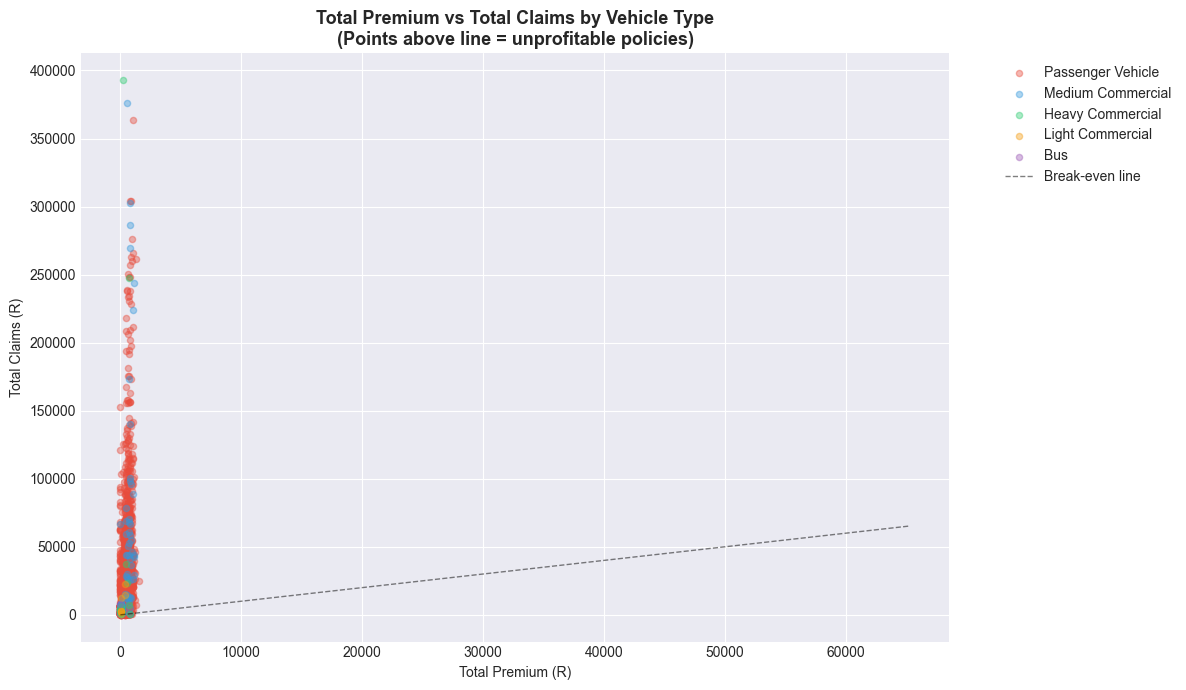

In [22]:
if 'VehicleType' in df.columns:
    sample = df[df['TotalClaims'] > 0].sample(
        min(3000, len(df[df['TotalClaims'] > 0])),
        random_state=42)

    plt.figure(figsize=(12, 7))
    vehicle_types = sample['VehicleType'].value_counts().head(6).index
    colors = ['#e74c3c','#3498db','#2ecc71',
              '#f39c12','#9b59b6','#1abc9c']

    for i, vtype in enumerate(vehicle_types):
        mask = sample['VehicleType'] == vtype
        plt.scatter(sample[mask]['TotalPremium'],
                   sample[mask]['TotalClaims'],
                   alpha=0.4, s=20, color=colors[i],
                   label=str(vtype))

    plt.plot([0, sample['TotalPremium'].max()],
             [0, sample['TotalPremium'].max()],
             'k--', linewidth=1, alpha=0.5, label='Break-even line')
    plt.title("Total Premium vs Total Claims by Vehicle Type\n"
              "(Points above line = unprofitable policies)",
              fontsize=13, fontweight='bold')
    plt.xlabel("Total Premium (R)")
    plt.ylabel("Total Claims (R)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig("notebooks/plot3_premium_vs_claims.png",
                dpi=100, bbox_inches='tight')
    plt.show()

## Plot 4: Loss Ratio by Vehicle Type

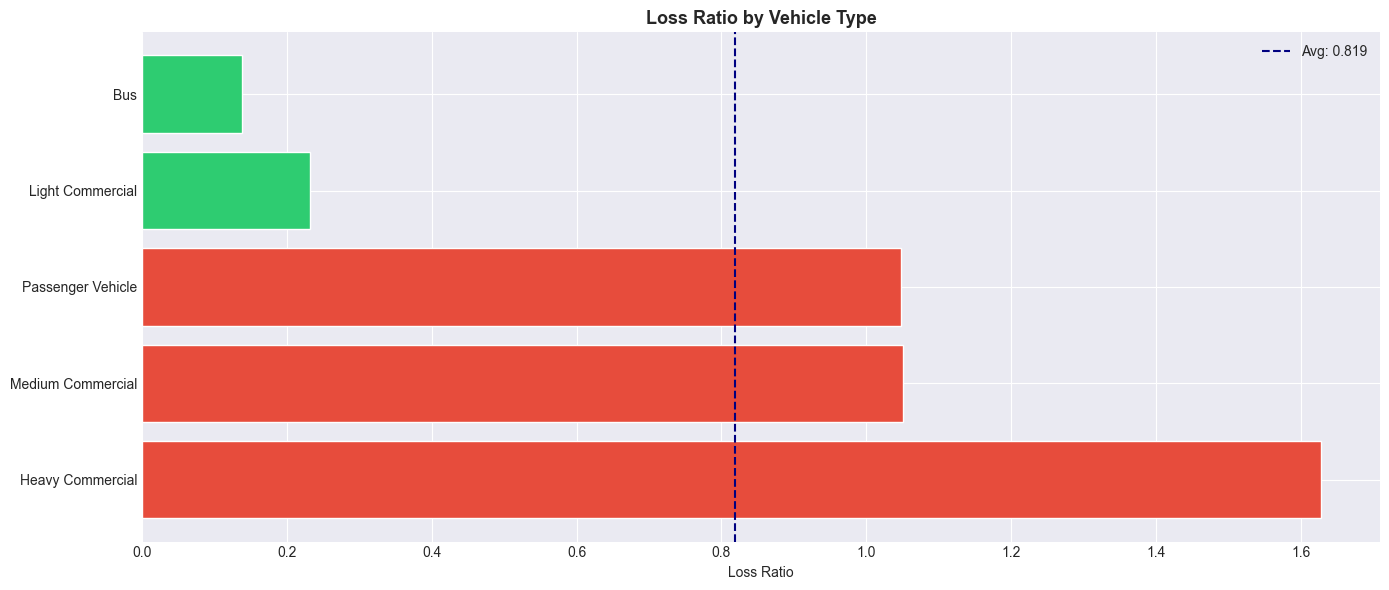

                   Portfolio_LR   Count
VehicleType                            
Heavy Commercial         1.6281    7401
Medium Commercial        1.0503   53985
Passenger Vehicle        1.0482  933598
Light Commercial         0.2321    3897
Bus                      0.1373     665


In [23]:
if 'VehicleType' in df.columns:
    vtype_stats = df.groupby('VehicleType').agg(
        Loss_Ratio=('LossRatio', 'mean'),
        Count=('PolicyID', 'count'),
        Total_Claims=('TotalClaims', 'sum'),
        Total_Premium=('TotalPremium', 'sum')
    ).round(4)
    vtype_stats['Portfolio_LR'] = (
        vtype_stats['Total_Claims'] / vtype_stats['Total_Premium']
    ).round(4)
    vtype_stats = vtype_stats[vtype_stats['Count'] > 100].sort_values(
        'Portfolio_LR', ascending=False)

    plt.figure(figsize=(14, 6))
    colors = ['#e74c3c' if x > 0.5 else '#2ecc71'
              for x in vtype_stats['Portfolio_LR']]
    plt.barh(vtype_stats.index, vtype_stats['Portfolio_LR'],
             color=colors, edgecolor='white')
    plt.axvline(x=vtype_stats['Portfolio_LR'].mean(),
                color='navy', linestyle='--',
                label=f"Avg: {vtype_stats['Portfolio_LR'].mean():.3f}")
    plt.title("Loss Ratio by Vehicle Type", fontsize=13, fontweight='bold')
    plt.xlabel("Loss Ratio")
    plt.legend()
    plt.tight_layout()
    plt.savefig("notebooks/plot4_loss_ratio_vehicle.png",
                dpi=100, bbox_inches='tight')
    plt.show()
    print(vtype_stats[['Portfolio_LR', 'Count']].head(10))

## Plot 5: Temporal Trends — Monthly Claim Frequency and Severity

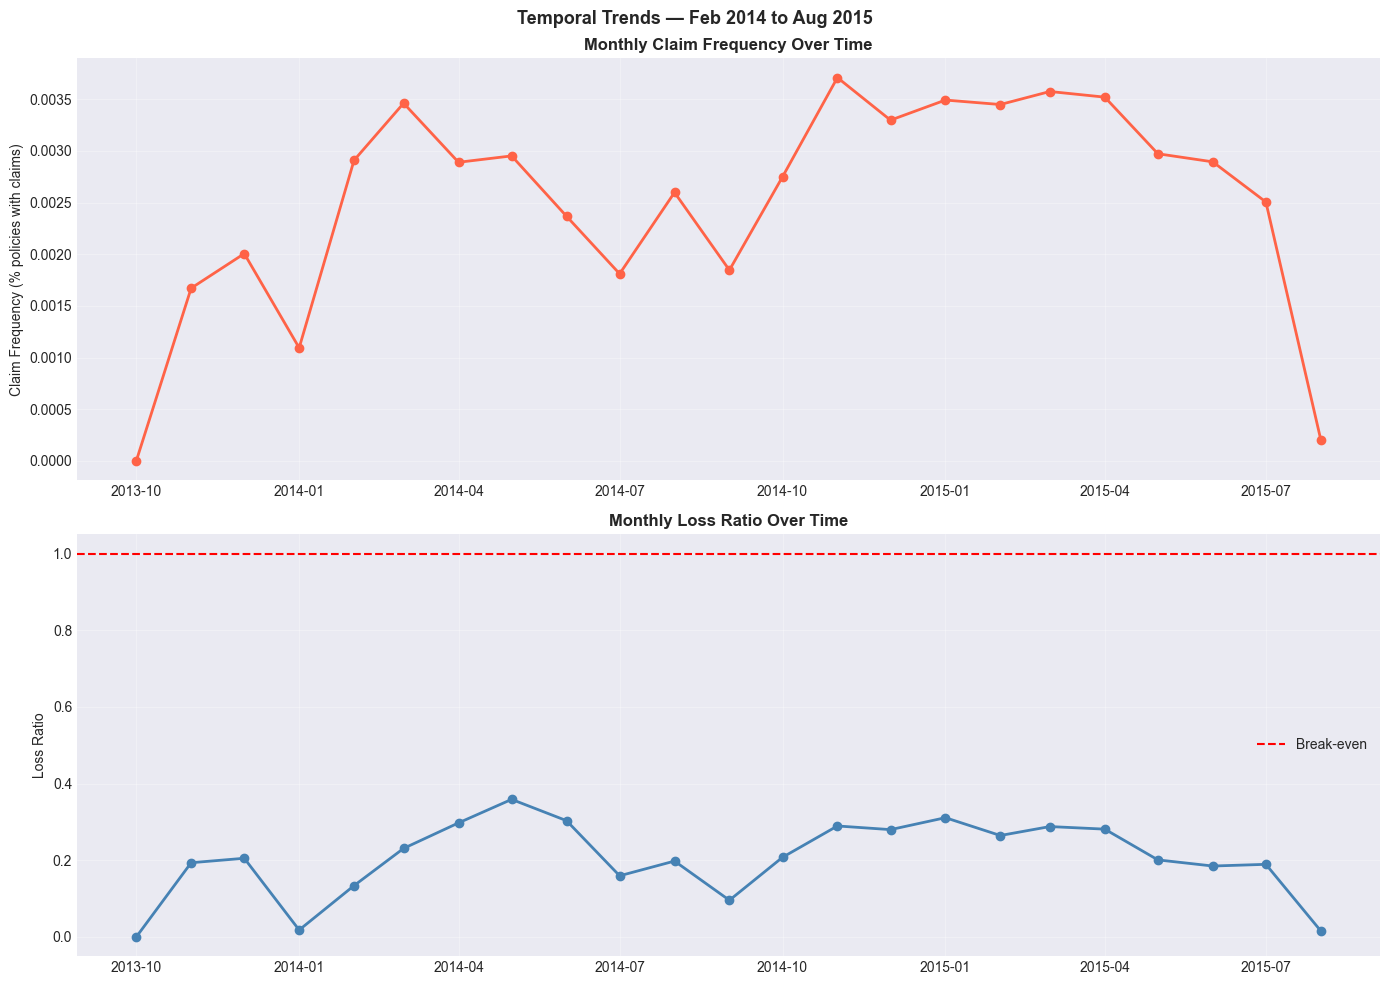

In [24]:
if 'TransactionMonth' in df.columns:
    df['YearMonth'] = df['TransactionMonth'].dt.to_period('M')
    monthly = df.groupby('YearMonth').agg(
        Claim_Frequency=('TotalClaims', lambda x: (x > 0).mean()),
        Avg_Claim_Severity=('TotalClaims', lambda x: x[x > 0].mean()),
        Avg_Premium=('TotalPremium', 'mean'),
        Loss_Ratio=('LossRatio', 'mean')
    ).reset_index()
    monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    axes[0].plot(monthly['YearMonth_dt'],
                 monthly['Claim_Frequency'],
                 marker='o', color='tomato', linewidth=2)
    axes[0].set_title("Monthly Claim Frequency Over Time",
                      fontweight='bold')
    axes[0].set_ylabel("Claim Frequency (% policies with claims)")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(monthly['YearMonth_dt'],
                 monthly['Loss_Ratio'],
                 marker='o', color='steelblue', linewidth=2)
    axes[1].axhline(y=1.0, color='red', linestyle='--',
                    label='Break-even')
    axes[1].set_title("Monthly Loss Ratio Over Time", fontweight='bold')
    axes[1].set_ylabel("Loss Ratio")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle("Temporal Trends — Feb 2014 to Aug 2015",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("notebooks/plot5_temporal_trends.png",
                dpi=100, bbox_inches='tight')
    plt.show()

## Plot 6: Top Vehicle Makes by Average Claim Amount

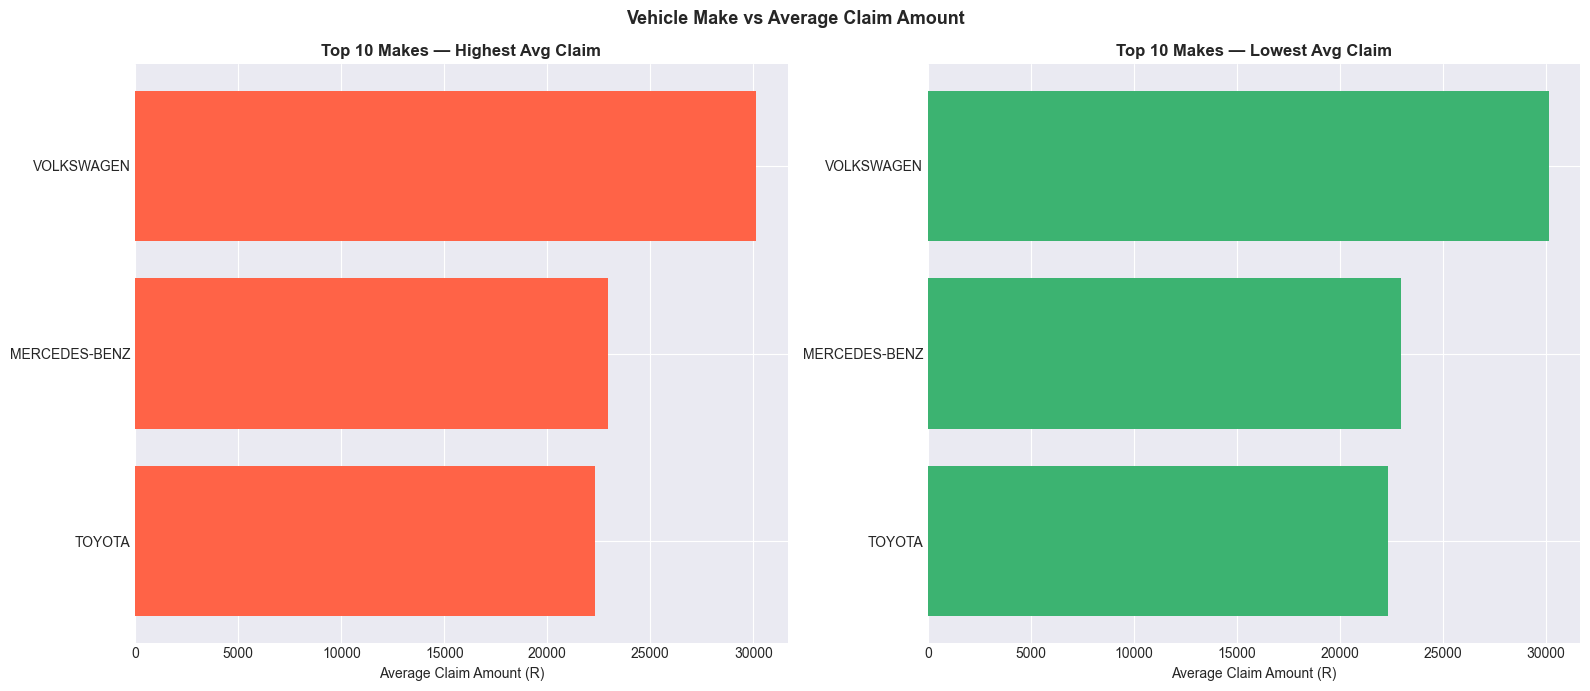

In [29]:
if 'make' in df.columns:
    make_stats = df[df['TotalClaims'] > 0].groupby('make').agg(
        Avg_Claim=('TotalClaims', 'mean'),
        Count=('PolicyID', 'count')
    ).round(2)
    make_stats = make_stats[make_stats['Count'] >= 50].sort_values(
        'Avg_Claim', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Highest claim makes
    top10 = make_stats.head(10)
    axes[0].barh(top10.index[::-1], top10['Avg_Claim'][::-1],
                 color='tomato')
    axes[0].set_title("Top 10 Makes — Highest Avg Claim",
                      fontweight='bold')
    axes[0].set_xlabel("Average Claim Amount (R)")

    # Lowest claim makes
    bot10 = make_stats.tail(10)
    axes[1].barh(bot10.index[::-1], bot10['Avg_Claim'][::-1],
                 color='mediumseagreen')
    axes[1].set_title("Top 10 Makes — Lowest Avg Claim",
                      fontweight='bold')
    axes[1].set_xlabel("Average Claim Amount (R)")

    plt.suptitle("Vehicle Make vs Average Claim Amount",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("notebooks/plot6_vehicle_make_claims.png",
                dpi=100, bbox_inches='tight')
    plt.show()

TotalPremium: 105,952 outliers (17.1%)
TotalClaims: 188 outliers (6.7%)
SumInsured: 104,294 outliers (10.4%)


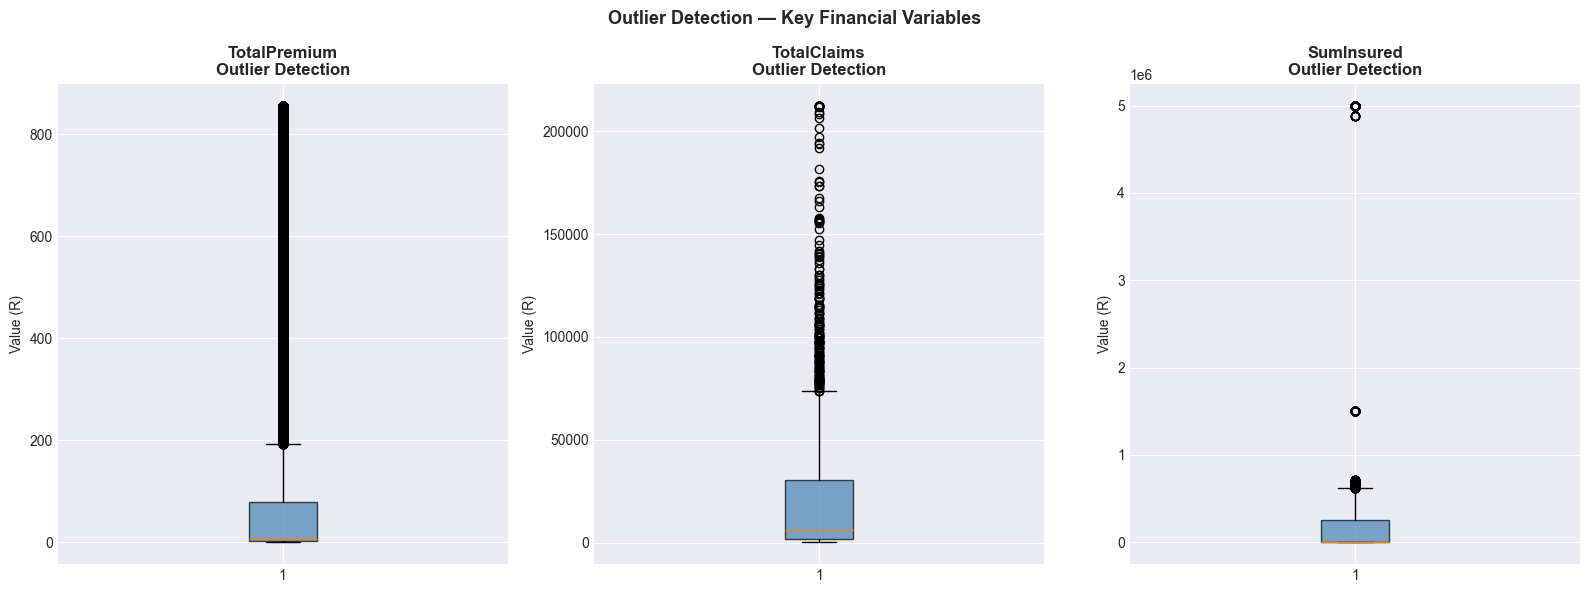

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, col in enumerate(['TotalPremium', 'TotalClaims', 'SumInsured']):
    if col in df.columns:
        data = df[col].dropna()
        data = data[data > 0]
        axes[i].boxplot(data.clip(upper=data.quantile(0.99)),
                        patch_artist=True,
                        boxprops=dict(facecolor='steelblue', alpha=0.7))
        axes[i].set_title(f"{col}\nOutlier Detection", fontweight='bold')
        axes[i].set_ylabel("Value (R)")

        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        iqr = q3 - q1
        outliers = data[(data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)]
        print(f"{col}: {len(outliers):,} outliers "
              f"({len(outliers)/len(data)*100:.1f}%)")

plt.suptitle("Outlier Detection — Key Financial Variables",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/plot7_outliers.png",
            dpi=100, bbox_inches='tight')
plt.show()

In [27]:
if 'Gender' in df.columns:
    gender_stats = df.groupby('Gender').agg(
        Avg_Loss_Ratio=('LossRatio', 'mean'),
        Total_Premium=('TotalPremium', 'sum'),
        Total_Claims=('TotalClaims', 'sum'),
        Count=('PolicyID', 'count')
    ).round(4)
    gender_stats['Portfolio_LR'] = (
        gender_stats['Total_Claims'] /
        gender_stats['Total_Premium']
    ).round(4)
    print("Loss Ratio by Gender:")
    print(gender_stats)

Loss Ratio by Gender:
               Avg_Loss_Ratio  Total_Premium  Total_Claims   Count  \
Gender                                                               
Female                 0.2479   3.044806e+05  2.502461e+05    6755   
Male                   0.1574   1.580143e+06  1.396704e+06   42817   
Not specified          0.2185   5.920275e+07  6.271410e+07  940990   

               Portfolio_LR  
Gender                       
Female               0.8219  
Male                 0.8839  
Not specified        1.0593  


In [28]:
print("=" * 60)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 60)
print(f"\nDataset: {df.shape[0]:,} policies, {df.shape[1]} features")
print(f"Period: {df['TransactionMonth'].min()} to "
      f"{df['TransactionMonth'].max()}")
print(f"\nPortfolio Metrics:")
print(f"  Overall Loss Ratio: {df['LossRatio'].mean():.4f}")
print(f"  Total Premium: R{df['TotalPremium'].sum():,.2f}")
print(f"  Total Claims: R{df['TotalClaims'].sum():,.2f}")
print(f"  Total Margin: R{df['Margin'].sum():,.2f}")
print(f"\nRisk Metrics:")
print(f"  Claim Frequency: {(df['TotalClaims']>0).mean()*100:.2f}%")
print(f"  Avg Claim (when claimed): "
      f"R{df[df['TotalClaims']>0]['TotalClaims'].mean():,.2f}")
if 'Province' in df.columns:
    highest_lr = df.groupby('Province')['LossRatio'].mean().idxmax()
    lowest_lr = df.groupby('Province')['LossRatio'].mean().idxmin()
    print(f"\nGeographic Risk:")
    print(f"  Highest risk province: {highest_lr}")
    print(f"  Lowest risk province: {lowest_lr}")
print("=" * 60)

EDA SUMMARY — KEY FINDINGS

Dataset: 1,000,098 policies, 55 features
Period: 2013-10-01 00:00:00 to 2015-08-01 00:00:00

Portfolio Metrics:
  Overall Loss Ratio: 0.2164
  Total Premium: R61,911,562.70
  Total Claims: R64,867,546.17
  Total Margin: R-2,955,983.47

Risk Metrics:
  Claim Frequency: 0.28%
  Avg Claim (when claimed): R23,273.39

Geographic Risk:
  Highest risk province: Gauteng
  Lowest risk province: Free State
